In [2]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('data/togo-dapaong_qc.csv', parse_dates=['Timestamp'])

In [4]:
df.columns

Index(['Timestamp', 'GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS',
       'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation',
       'TModA', 'TModB', 'Comments'],
      dtype='object')

In [5]:
df.tail()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
525595,2022-10-24 23:56:00,-0.8,0.0,0.0,0.0,0.0,25.2,53.8,0.0,0.0,0.0,0.0,0.0,977,0,0.0,24.3,24.0,NaN
525596,2022-10-24 23:57:00,-0.9,0.0,0.0,0.0,0.0,25.3,53.5,0.0,0.0,0.0,0.0,0.0,977,0,0.0,24.3,24.0,NaN
525597,2022-10-24 23:58:00,-1.0,0.0,0.0,0.0,0.0,25.3,53.4,0.0,0.0,0.0,0.0,0.0,977,0,0.0,24.2,23.9,NaN
525598,2022-10-24 23:59:00,-1.1,0.0,0.0,0.0,0.0,25.4,53.5,0.0,0.0,0.0,0.0,0.0,977,0,0.0,24.1,23.8,NaN
525599,2022-10-25 00:00:00,-1.2,0.0,0.0,0.0,0.0,25.4,52.3,0.0,0.0,0.0,0.0,0.0,977,0,0.0,24.1,23.8,NaN


In [6]:
df.describe()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,2022-04-25 12:00:30.000000768,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
min,2021-10-25 00:01:00,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,2022-01-24 06:00:45,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2022-04-25 12:00:30,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,2022-07-25 18:00:15,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,2022-10-25 00:00:00,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN
std,NaN,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN


In [7]:
df.isna().value_counts()

Timestamp  GHI    DNI    DHI    ModA   ModB   Tamb   RH     WS     WSgust  WSstdev  WD     WDstdev  BP     Cleaning  Precipitation  TModA  TModB  Comments
False      False  False  False  False  False  False  False  False  False   False    False  False    False  False     False          False  False  True        525600
Name: count, dtype: int64

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric columns in df:", numeric_cols)

Numeric columns in df: ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB', 'Comments']


In [9]:
print("\n--- Summary Statistics of Numeric Columns ---")
print(df[numeric_cols].describe())


--- Summary Statistics of Numeric Columns ---
                 GHI            DNI            DHI           ModA  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      230.555040     151.258469     116.444352     226.144375   
std       322.532347     250.956962     156.520714     317.346938   
min       -12.700000       0.000000       0.000000       0.000000   
25%        -2.200000       0.000000       0.000000       0.000000   
50%         2.100000       0.000000       2.500000       4.400000   
75%       442.400000     246.400000     215.700000     422.525000   
max      1424.000000    1004.500000     805.700000    1380.000000   

                ModB           Tamb             RH             WS  \
count  525600.000000  525600.000000  525600.000000  525600.000000   
mean      219.568588      27.751788      55.013160       2.368093   
std       307.932510       4.758023      28.778732       1.462668   
min         0.000000      14.900000       3.300000     

In [10]:
missing_values = df.isna().sum()

In [11]:
threshold = 0.05 * len(df)
high_null_columns = missing_values[missing_values > threshold]

In [12]:
high_null_columns

Comments    525600
dtype: int64

In [13]:
cols_to_check = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

z_scores = df[cols_to_check].apply(zscore)

outliers = (np.abs(z_scores) > 3).any(axis=1)
outlier_df = df[outliers]


In [25]:
for col in cols_to_check:
    df[col] = df[col].fillna(df[col].median())

In [14]:
country = 'togo-dapaong_qc'
df.to_csv(f'data/{country}_clean.csv', index=False)

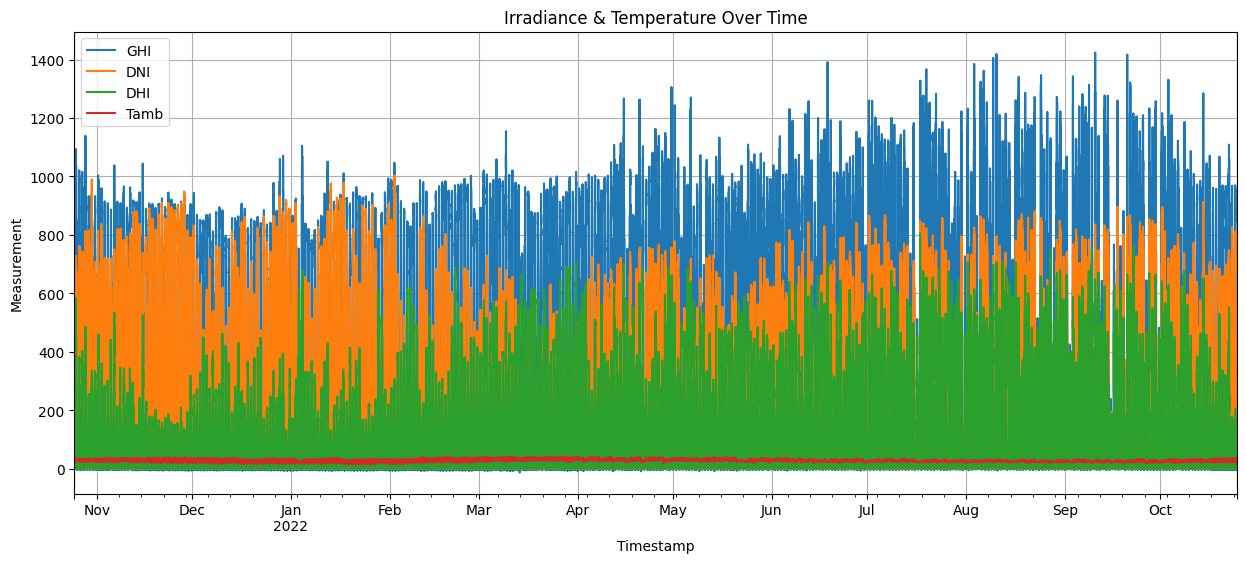

In [30]:
time_cols = ['GHI', 'DNI', 'DHI', 'Tamb']

df.set_index('Timestamp')[time_cols].plot(figsize=(15, 6), title="Irradiance & Temperature Over Time")
plt.ylabel("Measurement")
plt.grid()
plt.show()

<Axes: title={'center': 'Monthly Averages of Solar & Temp'}, xlabel='Month'>

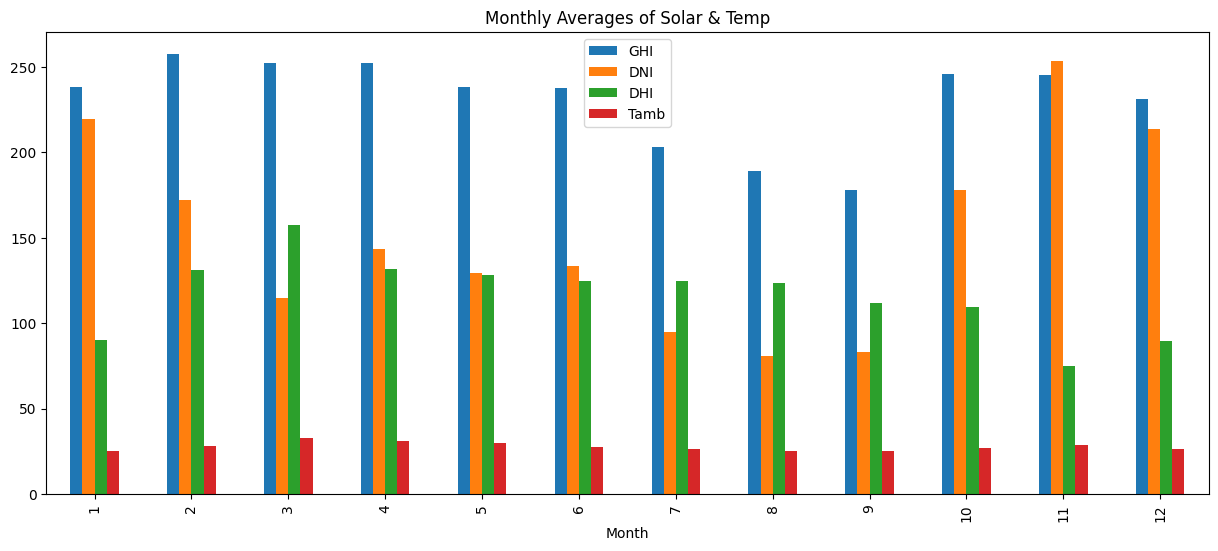

In [31]:
df['Month'] = df['Timestamp'].dt.month
monthly_avg = df.groupby('Month')[time_cols].mean()
monthly_avg.plot(kind='bar', figsize=(15, 6), title="Monthly Averages of Solar & Temp")


Text(0, 0.5, 'Sensor Output')

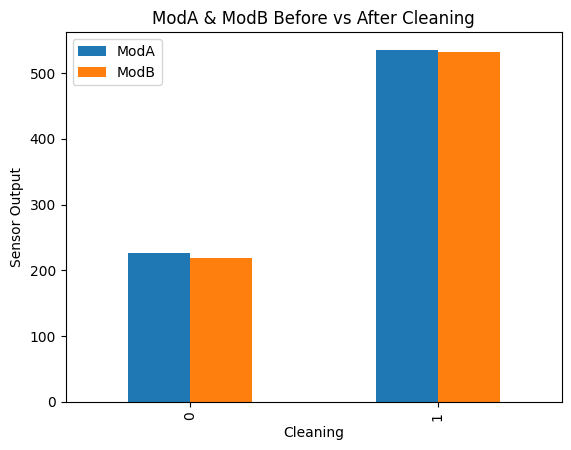

In [32]:
df['Cleaning'] = df['Cleaning'].fillna('Unknown')
cleaning_effect = df.groupby('Cleaning')[['ModA', 'ModB']].mean()

cleaning_effect.plot(kind='bar', title='ModA & ModB Before vs After Cleaning')
plt.ylabel('Sensor Output')

Text(0.5, 1.0, 'Correlation Heatmap')

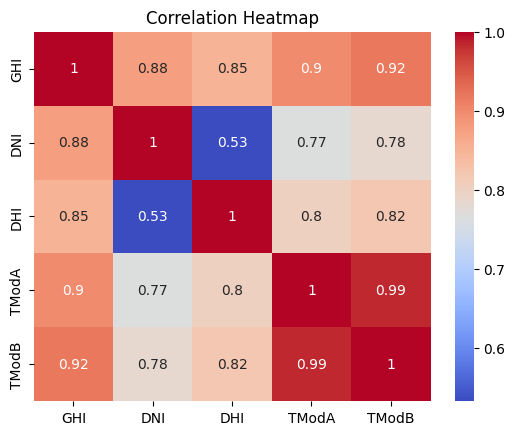

In [34]:
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']
correlation = df[corr_cols].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')

Text(0.5, 1.0, 'RH vs Tamb')

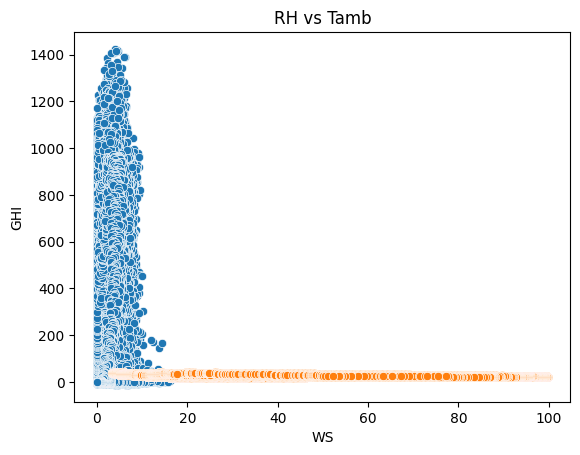

In [35]:
sns.scatterplot(x='WS', y='GHI', data=df)
plt.title('Wind Speed vs GHI')

sns.scatterplot(x='RH', y='Tamb', data=df)
plt.title('RH vs Tamb')

Text(0.5, 1.0, 'Wind Direction Distribution')

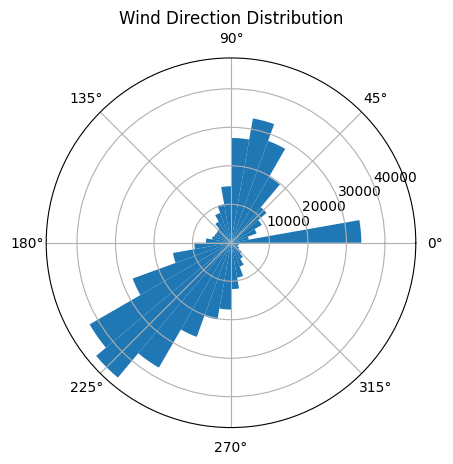

In [36]:
ax = plt.subplot(111, polar=True)
wd_rad = np.radians(df['WD'].dropna())
ax.hist(wd_rad, bins=36)
plt.title("Wind Direction Distribution")

Text(0.5, 0, 'WS')

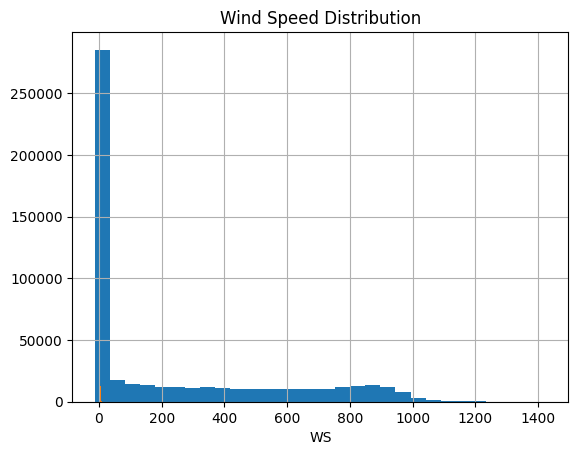

In [37]:
df['GHI'].hist(bins=30)
plt.title('GHI Distribution')
plt.xlabel('GHI')

df['WS'].hist(bins=30)
plt.title('Wind Speed Distribution')
plt.xlabel('WS')

Text(0.5, 1.0, 'RH vs GHI Colored by Tamb')

C:\Users\Hawi.Kebebew\AppData\Roaming\Python\Python311\site-packages\IPython\core\events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
C:\Users\Hawi.Kebebew\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


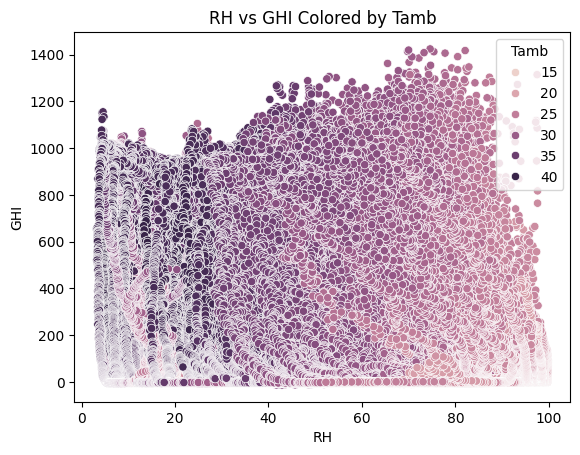

In [38]:
sns.scatterplot(x='RH', y='GHI', hue='Tamb', data=df)
plt.title('RH vs GHI Colored by Tamb')

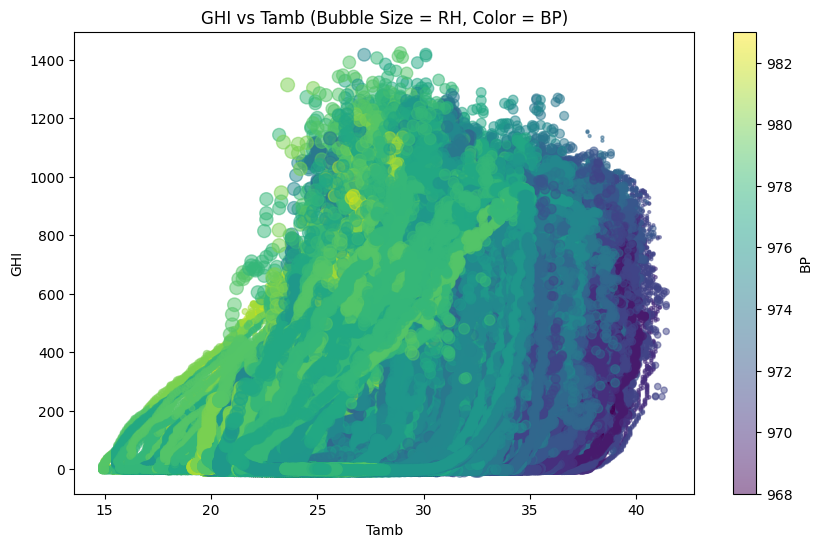

In [39]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Tamb'], df['GHI'], s=df['RH'], alpha=0.5, c=df['BP'], cmap='viridis')
plt.xlabel('Tamb')
plt.ylabel('GHI')
plt.title('GHI vs Tamb (Bubble Size = RH, Color = BP)')
plt.colorbar(label='BP')